# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 90 dias | Ventana salida: 5 dias

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [1]:
VENTANA_ENTRADA = 90   # dias de entrada
VENTANA_SALIDA  = 5   # dias de salida (promedio)


In [2]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import construir_baseline_lineal, construir_dense, construir_dense_v2, construir_dense_v3, construir_dense_v4, construir_dense_v5, construir_dense_v6, construir_recurrente, construir_conv1d, construir_mixto
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae
from utilidades.tuning import ofat_search, plot_best_history

CALLBACKS = [
   # EarlyStopping(monitor ='val_loss', patience=12, min_delta=1e-5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor ='val_loss', factor=0.5, patience=3,  min_delta=1e-5, min_lr=1e-8, verbose=1),
]


---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [3]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16096, 90, 23)  |  y: (16096, 23)
Train: (13761, 90, 23)  Val: (725, 90, 23)  Test: (1610, 90, 23)


## 1.2 Baselines

In [4]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.005046  0.004876  0.006317         0
BuyAndHold   0.005398  0.004311  0.005595         0


## 1.3 Modelo Dense (MLP)

In [5]:
modelo_lineal = construir_baseline_lineal(X_train_plano.shape[1], y_train.shape[1])
modelo_lineal.summary()
hist_dense_lineal = modelo_lineal.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
   epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Lineal_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 23)             │        47,633 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,633 (186.07 KB)

 Trainable params: 47,633 (186.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.0191 - val_loss: 0.0147 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0178 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0167 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0157 - val_loss: 0.0127 - learning_rate: 0.0010
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0149 - val_loss: 0.0122 - learning_rate: 0.0010
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0142 - val_loss: 0.0118 - learning_rate: 0.0010
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0136 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0130 - val_loss: 0.0110 - learning_rate: 0.0010
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0125 - val_loss: 0.0106 - learning_rate: 0.0010
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━

In [6]:
modelo_dense_1 = construir_dense(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_1.summary()
hist_dense_1 = modelo_dense_1.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       530,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 566,039 (2.16 MB)

 Trainable params: 566,039 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0186 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0117 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0100
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0098 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0085 - val_loss: 0.0059 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0077 - val_loss: 0.0054 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0072
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0071 - val_loss: 0.0050 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0066 - val_loss: 0.0049 - le

In [7]:
modelo_dense_2 = construir_dense_v2(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_2.summary()
hist_dense_2 = modelo_dense_2.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

Model: "Dense_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       265,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,183 (1.05 MB)

 Trainable params: 276,183 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - loss: 0.0141 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0094 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0075
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0074 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0066 - val_loss: 0.0050 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0064 - val_loss: 0.0049 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0062
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0062 - val_loss: 0.0047 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0060 - val_loss: 0.0046 - lea

In [8]:
modelo_dense_3 = construir_dense_v3(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_3.summary()
hist_dense_3 = modelo_dense_3.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

Model: "Dense_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │     1,060,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,234,327 (4.71 MB)

 Trainable params: 1,234,327 (4.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.0111 - val_loss: 0.0068 - learning_rate: 1.0000e-04
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0096 - val_loss: 0.0059 - learning_rate: 1.0000e-04
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0086
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0084 - val_loss: 0.0054 - learning_rate: 1.0000e-04
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0076 - val_loss: 0.0052 - learning_rate: 5.0000e-05
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0073 - val_loss: 0.0051 - learning_rate: 5.0000e-05
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0071
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0070 - val_loss: 0.0050 - learning_rate: 5.0000e-05
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0069 - val_los

In [9]:
modelo_dense_4 = construir_dense_v4(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_4.summary()
hist_dense_4 = modelo_dense_4.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)


Model: "Dense_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 128)            │       265,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,839 (1.05 MB)

 Trainable params: 274,839 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.0496 - val_loss: 0.0388 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0426 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0390
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0385 - val_loss: 0.0337 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0356 - val_loss: 0.0325 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0341 - val_loss: 0.0312 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0329
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0327 - val_loss: 0.0300 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0315 - val_loss: 0.0294 - le

In [10]:
modelo_dense_5 = construir_dense_v5(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_5.summary()
hist_dense_5 = modelo_dense_5.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

Model: "Dense_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │       530,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,087 (2.05 MB)

 Trainable params: 536,087 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - loss: 0.0262 - val_loss: 0.0161 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0221 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0201
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0199 - val_loss: 0.0131 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0184 - val_loss: 0.0124 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0176 - val_loss: 0.0117 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0168
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0167 - val_loss: 0.0109 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0159 - val_loss: 0.0106 - le

In [11]:
modelo_dense_6 = construir_dense_v6(X_train_plano.shape[1], y_train.shape[1])
modelo_dense_6.summary()
hist_dense_6 = modelo_dense_6.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=50, batch_size=10000, callbacks=CALLBACKS, verbose=1)

Model: "Dense_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │        66,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,671 (311.21 KB)

 Trainable params: 79,671 (311.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0181 - val_loss: 0.0104 - learning_rate: 0.0010
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0152 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 3/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0135
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0132 - val_loss: 0.0077 - learning_rate: 0.0010
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0115 - val_loss: 0.0072 - learning_rate: 5.0000e-04
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0108 - val_loss: 0.0069 - learning_rate: 5.0000e-04
Epoch 6/50
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0103
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0103 - val_loss: 0.0065 - learning_rate: 5.0000e-04
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0097 - val_loss: 0.0063 - le

{'modelo': 'Lineal', 'mae_train': 0.004862782908435184, 'mae_val': 0.004850436009334791, 'mae_test': 0.006249257683095361, 'n_params': 47633}


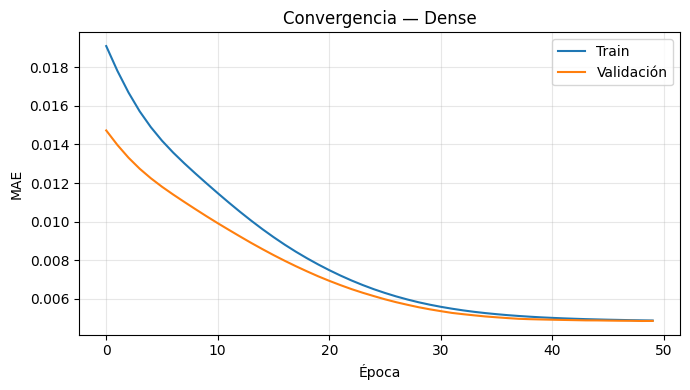

In [12]:
graficar_convergencia(hist_dense_lineal, 'Dense')
resultado_lineal = evaluar_modelo(modelo_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
print(resultado_lineal)

{'modelo': 'Dense', 'mae_train': 0.005349024388859817, 'mae_val': 0.0043242504050856655, 'mae_test': 0.005660736775585728, 'n_params': 566039}


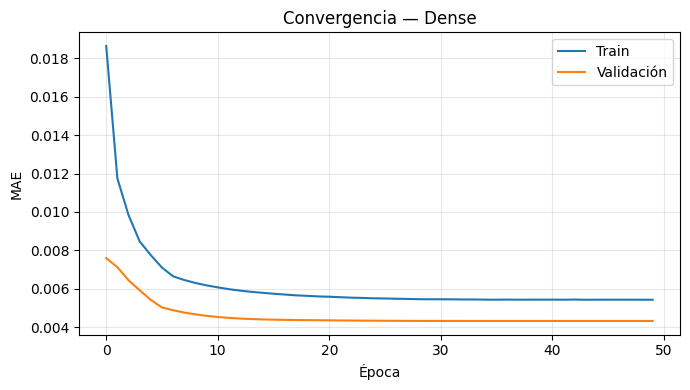

In [13]:
graficar_convergencia(hist_dense_1, 'Dense')
resultado_dense_1 = evaluar_modelo(modelo_dense_1, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_1)

{'modelo': 'Dense', 'mae_train': 0.0054844443544701, 'mae_val': 0.00439345275385421, 'mae_test': 0.005710677727824399, 'n_params': 276183}


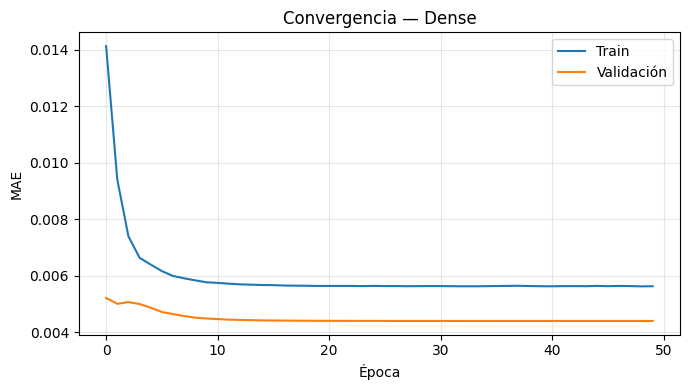

In [14]:
graficar_convergencia(hist_dense_2, 'Dense')
resultado_dense_2 = evaluar_modelo(modelo_dense_2, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_2)

{'modelo': 'Dense', 'mae_train': 0.005963998532851122, 'mae_val': 0.00478848158430461, 'mae_test': 0.006307241579407065, 'n_params': 1234327}


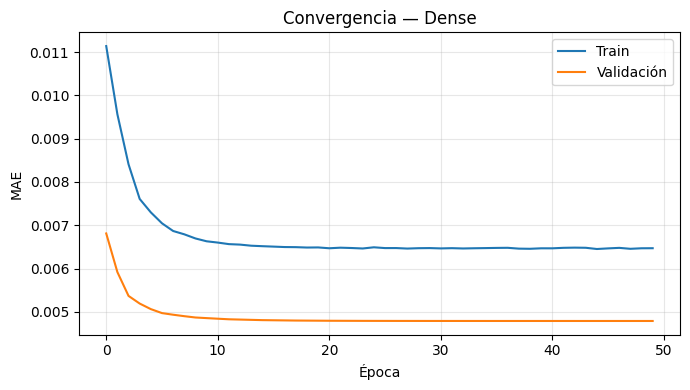

In [15]:
graficar_convergencia(hist_dense_3, 'Dense')
resultado_dense_3 = evaluar_modelo(modelo_dense_3, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_3)

{'modelo': 'Dense', 'mae_train': 0.0056946143916881695, 'mae_val': 0.004601139765378742, 'mae_test': 0.0060267216763409456, 'n_params': 274839}


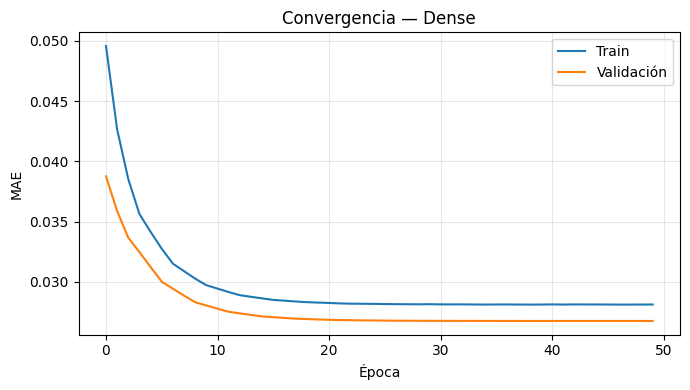

In [16]:
graficar_convergencia(hist_dense_4, 'Dense')
resultado_dense_4 = evaluar_modelo(modelo_dense_4, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_4)

{'modelo': 'Dense', 'mae_train': 0.009930159179647556, 'mae_val': 0.009121346805502115, 'mae_test': 0.011559625256621412, 'n_params': 536087}


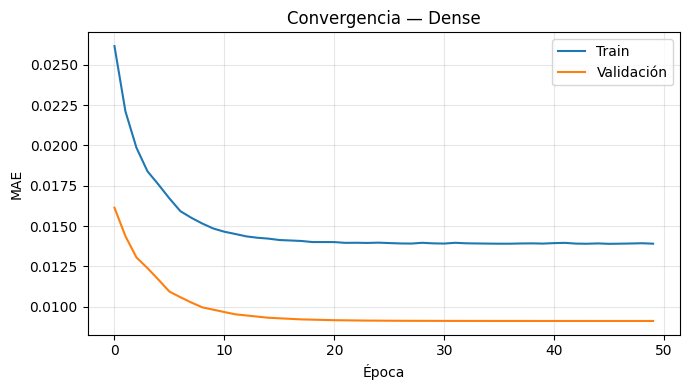

In [17]:
graficar_convergencia(hist_dense_5, 'Dense')
resultado_dense_5 = evaluar_modelo(modelo_dense_5, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_5)

{'modelo': 'Dense', 'mae_train': 0.009930159179647556, 'mae_val': 0.009121346805502115, 'mae_test': 0.011559625256621412, 'n_params': 536087}


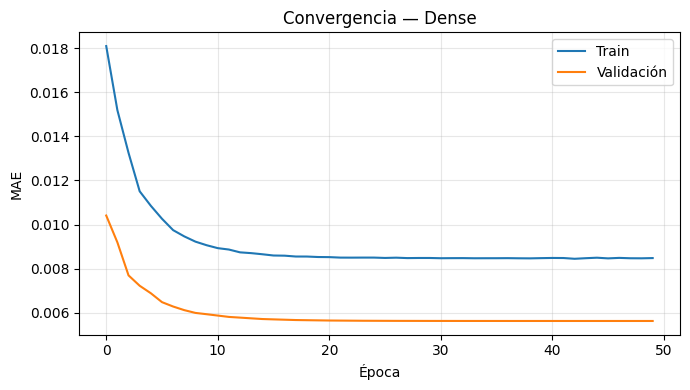

In [18]:
graficar_convergencia(hist_dense_6, 'Dense')
resultado_dense_6 = evaluar_modelo(modelo_dense_5, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense_6)

In [19]:
base_cfg = {
    "epochs": 75,
    "batch_size": 500,
    "lr": 1e-3,          # se aplica por recompilación runtime
    "factor": 0.5,
    "rlr_patience": 3,
    "min_delta": 1e-5,
    "min_lr": 1e-6,
    "seed": 42,
    "verbose": 0 # Para evitar imprimir cada epoch durante el tuning
}

search_steps = [
    ("lr", [1e-3, 5e-4, 3e-4, 1e-4]),
    ("batch_size", [250, 1000, 5000, 10000, 14000]),
    ("factor", [0.3, 0.5, 0.7]),
    ("rlr_patience", [2, 3, 5]),
    ("min_delta", [1e-6, 1e-5, 1e-4]),
    ("min_lr", [1e-6, 1e-5, 1e-4]),
    ("epochs", [30, 50, 80, 100])
]

In [20]:
import json

dense_models = [
    "construir_dense",
    "construir_dense_v2",
    "construir_dense_v3",
    "construir_dense_v4",
    "construir_dense_v5",
    "construir_dense_v6",
]

resumen = []
best_histories = {}

for fn_name in dense_models:
    print(f"\n{'='*60}\nBuscando hiperparámetros para {fn_name}...\n{'='*60}")

    best_cfg, best_val, best_epoch, best_hist, best_model, df_trials = ofat_search(
        model_fn_name=fn_name,
        base_cfg=base_cfg.copy(),
        search_steps=search_steps,
        X_train=X_train, y_train=y_train,
        X_val=X_val, y_val=y_val
    )

    met = evaluar_modelo(
        best_model,
        X_train_plano, y_train,
        X_val_plano, y_val,
        X_test_plano, y_test,
        nombre=fn_name
    )

    resumen.append({
        "modelo": fn_name,
        "mae_train": met["mae_train"],      
        "mae_val": met["mae_val"],          
        "mae_test": met["mae_test"],        
        "n_params": met["n_params"],
        "best_val_loss": best_val,
        "best_epoch": best_epoch,
        "best_cfg": json.dumps(best_cfg, ensure_ascii=False)
    })
    best_histories[fn_name] = best_hist

# Tabla resumen
resumen_df = pd.DataFrame(resumen).sort_values("mae_test").reset_index(drop=True)
cols = ["modelo", "mae_train", "mae_test", "n_params", "best_cfg"]
tabla = resumen_df[cols].copy()
tabla["mae_train"] = tabla["mae_train"].map(lambda x: f"{x:.6f}")
tabla["mae_test"] = tabla["mae_test"].map(lambda x: f"{x:.6f}")
tabla["mejor_test"] = ""

best_idx = resumen_df["mae_test"].idxmin()
tabla.loc[best_idx, "mejor_test"] = "<-- MEJOR"

display(tabla)

# Pintar TODAS las mejores curvas (una por modelo)
n = len(best_histories)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, (name, hist) in zip(axes, best_histories.items()):
    best_ep = int(np.argmin(hist.history["val_loss"])) + 1
    ax.plot(hist.history["loss"], label="Train")
    ax.plot(hist.history["val_loss"], label="Validación")
    ax.axvline(best_ep - 1, color="gray", ls="--", alpha=0.6, label=f"Mejor época: {best_ep}")
    ax.set_title(f"{name} (ent{VENTANA_ENTRADA}_sal{VENTANA_SALIDA})")
    ax.set_xlabel("Época")
    ax.set_ylabel("MAE")
    ax.grid(alpha=0.3)
    ax.legend()

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


plt.tight_layout()
plt.show()

best_cfg, best_val, best_epoch, best_hist, best_model, df_trials = ofat_search(
    model_fn_name="construir_dense_v2",
    base_cfg=base_cfg,
    search_steps=search_steps,
    X_train=X_train, y_train=y_train,      # puede ser 3D; se aplana solo para Dense
    X_val=X_val, y_val=y_val
)

print("Mejor configuración:", best_cfg)
print(f"Mejor val_loss: {best_val:.6f} (época {best_epoch})")
display(df_trials.head(15))
plot_best_history(best_hist, "Convergencia — Mejor configuración (Dense_v2)")



Buscando hiperparámetros para construir_dense...

lr           -> mejor: 0.0001 | score=0.004312 | val_loss=0.004312 | gap=0.001104 (epoca 17)
batch_size   -> mejor: 500 | score=0.004312 | val_loss=0.004312 | gap=0.001104 (epoca 17)
factor       -> mejor: 0.3 | score=0.004311 | val_loss=0.004311 | gap=0.001107 (epoca 17)
rlr_patience -> mejor: 5 | score=0.004311 | val_loss=0.004311 | gap=0.001105 (epoca 16)
min_delta    -> mejor: 1e-05 | score=0.004311 | val_loss=0.004311 | gap=0.001105 (epoca 16)
min_lr       -> mejor: 1e-06 | score=0.004311 | val_loss=0.004311 | gap=0.001105 (epoca 16)
epochs       -> mejor: 75 | score=0.004311 | val_loss=0.004311 | gap=0.001105 (epoca 16)

Buscando hiperparámetros para construir_dense_v2...


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


lr           -> mejor: 0.001 | score=0.004314 | val_loss=0.004314 | gap=0.001083 (epoca 16)
batch_size   -> mejor: 250 | score=0.004311 | val_loss=0.004311 | gap=0.001104 (epoca 2)
factor       -> mejor: 0.5 | score=0.004311 | val_loss=0.004311 | gap=0.001104 (epoca 2)
rlr_patience -> mejor: 3 | score=0.004311 | val_loss=0.004311 | gap=0.001104 (epoca 2)
min_delta    -> mejor: 1e-05 | score=0.004311 | val_loss=0.004311 | gap=0.001104 (epoca 2)
min_lr       -> mejor: 1e-06 | score=0.004311 | val_loss=0.004311 | gap=0.001104 (epoca 2)
epochs       -> mejor: 75 | score=0.004311 | val_loss=0.004311 | gap=0.001104 (epoca 2)

Buscando hiperparámetros para construir_dense_v3...


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


lr           -> mejor: 0.0001 | score=0.004311 | val_loss=0.004311 | gap=0.001101 (epoca 6)
batch_size   -> mejor: 500 | score=0.004311 | val_loss=0.004311 | gap=0.001101 (epoca 6)
factor       -> mejor: 0.5 | score=0.004311 | val_loss=0.004311 | gap=0.001101 (epoca 6)
rlr_patience -> mejor: 3 | score=0.004311 | val_loss=0.004311 | gap=0.001101 (epoca 6)
min_delta    -> mejor: 1e-05 | score=0.004311 | val_loss=0.004311 | gap=0.001101 (epoca 6)
min_lr       -> mejor: 1e-06 | score=0.004311 | val_loss=0.004311 | gap=0.001101 (epoca 6)


KeyboardInterrupt: 

## 1.3.1 Tuning Dense con successive halving

 ============================================================ Successive halving para construir_dense ============================================================
Ronda corta: 24/384 candidatos con 20 epocas


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


construir_dense: 1/24 candidatos cortos | mejor score=0.004319
construir_dense: 6/24 candidatos cortos | mejor score=0.004307
construir_dense: 12/24 candidatos cortos | mejor score=0.004307
construir_dense: 18/24 candidatos cortos | mejor score=0.004307
construir_dense: 24/24 candidatos cortos | mejor score=0.004307
Ronda final: 6 candidatos con 150 epocas


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


final 1/6 | mejor score=0.004307 | val_loss=0.004307
final 2/6 | mejor score=0.004307 | val_loss=0.004307
final 3/6 | mejor score=0.004307 | val_loss=0.004307
final 4/6 | mejor score=0.004307 | val_loss=0.004307
final 5/6 | mejor score=0.004307 | val_loss=0.004307
final 6/6 | mejor score=0.004307 | val_loss=0.004307
 ============================================================ Successive halving para construir_dense_v2 ============================================================
Ronda corta: 24/384 candidatos con 20 epocas


...

final 1/6 | mejor score=0.004315 | val_loss=0.004315
final 2/6 | mejor score=0.004315 | val_loss=0.004315
final 3/6 | mejor score=0.004315 | val_loss=0.004315
final 4/6 | mejor score=0.004315 | val_loss=0.004315
final 5/6 | mejor score=0.004315 | val_loss=0.004315
final 6/6 | mejor score=0.004315 | val_loss=0.004315


,modelo,funcion,mae_train,mae_val,mae_test,n_params,best_val_loss,best_epoch,best_cfg
0,construir_dense_v2_halving,construir_dense_v2,0.005401,0.004309,0.005589,276183,0.004309,11,"{'epochs': 150, 'batch_size': 128, 'lr': 0.000..."
1,construir_dense_v4_halving,construir_dense_v4,0.005401,0.004309,0.005589,274839,0.004309,29,"{'epochs': 150, 'batch_size': 128, 'lr': 0.000..."
2,construir_dense_v6_halving,construir_dense_v6,0.005388,0.004315,0.005594,79671,0.004315,15,"{'epochs': 150, 'batch_size': 64, 'lr': 5e-05,..."
3,construir_dense_v3_halving,construir_dense_v3,0.005208,0.004309,0.005605,1234327,0.004309,7,"{'epochs': 150, 'batch_size': 64, 'lr': 0.0003..."
4,construir_dense_halving,construir_dense,0.005274,0.004307,0.005615,566039,0.004307,10,"{'epochs': 150, 'batch_size': 256, 'lr': 0.000..."
5,construir_dense_v5_halving,construir_dense_v5,0.005031,0.004470,0.005800,536087,0.004470,10,"{'epochs': 150, 'batch_size': 128, 'lr': 0.000..."


Mejor modelo Dense: construir_dense_v2
Mejor configuracion Dense: {'epochs': 150, 'batch_size': 128, 'lr': 0.0003, 'factor': 0.7, 'rlr_patience': 5, 'min_delta': 1e-06, 'min_lr': 1e-06, 'seed': 42, 'verbose': 0, 'es_patience': 25, 'restore_best_weights': True}
Mejor val_loss: 0.004309 en epoca 11


,trial,score,best_val_loss,best_train_loss,train_val_gap,best_epoch,epochs,batch_size,lr,factor,rlr_patience,min_delta,min_lr,seed,verbose,es_patience,restore_best_weights
0,9,0.004309,0.004309,0.005401,0.001092,11,20,128,0.00030,0.7,5,0.000001,1.000000e-06,42,0,25,True
1,3,0.004310,0.004310,0.005401,0.001092,10,20,128,0.00050,0.5,8,0.000005,1.000000e-06,42,0,25,True
2,13,0.004311,0.004311,0.005413,0.001102,6,20,64,0.00010,0.5,8,0.000001,1.000000e-06,42,0,25,True
3,5,0.004311,0.004311,0.005403,0.001092,19,20,256,0.00050,0.7,8,0.000001,1.000000e-07,42,0,25,True
4,7,0.004311,0.004311,0.005402,0.001091,10,20,64,0.00030,0.5,5,0.000005,1.000000e-06,42,0,25,True
5,1,0.004311,0.004311,0.005400,0.001089,20,20,64,0.00050,0.5,5,0.000001,1.000000e-07,42,0,25,True
6,2,0.004311,0.004311,0.005402,0.001091,20,20,64,0.00050,0.7,5,0.000010,1.000000e-07,42,0,25,True
7,8,0.004311,0.004311,0.005402,0.001090,20,20,64,0.00030,0.7,8,0.000005,1.000000e-07,42,0,25,True
8,4,0.004312,0.004312,0.005402,0.001091,16,20,256,0.00050,0.5,5,0.000001,1.000000e-06,42,0,25,True
9,19,0.004314,0.004314,0.005469,0.001155,5,20,64,0.00005,0.5,8,0.000010,1.000000e-06,42,0,25,True


,trial,score,best_val_loss,best_train_loss,train_val_gap,best_epoch,epochs,batch_size,lr,factor,rlr_patience,min_delta,min_lr,seed,verbose,es_patience,restore_best_weights
0,1,0.004309,0.004309,0.005401,0.001092,11,150,128,0.0003,0.7,5,0.000001,1.000000e-06,42,0,25,True
1,2,0.004310,0.004310,0.005401,0.001092,10,150,128,0.0005,0.5,8,0.000005,1.000000e-06,42,0,25,True
2,4,0.004310,0.004310,0.005401,0.001091,24,150,256,0.0005,0.7,8,0.000001,1.000000e-07,42,0,25,True
3,3,0.004311,0.004311,0.005413,0.001102,6,150,64,0.0001,0.5,8,0.000001,1.000000e-06,42,0,25,True
4,5,0.004311,0.004311,0.005402,0.001091,10,150,64,0.0003,0.5,5,0.000005,1.000000e-06,42,0,25,True
5,6,0.004311,0.004311,0.005400,0.001089,20,150,64,0.0005,0.5,5,0.000001,1.000000e-07,42,0,25,True


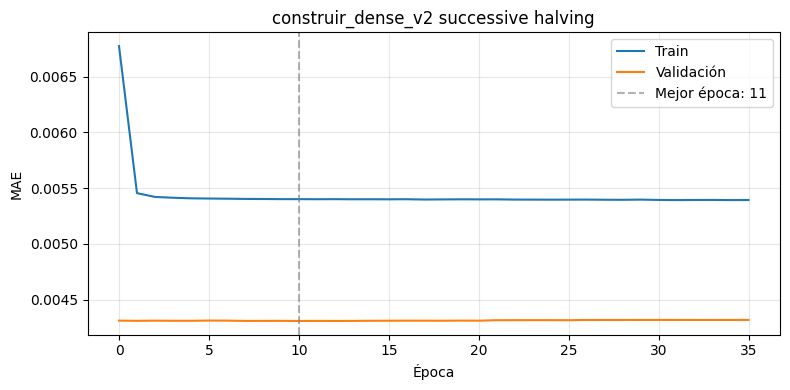

{'modelo': 'construir_dense_v2_halving', 'mae_train': 0.005400663542186419, 'mae_val': 0.004309365703328095, 'mae_test': 0.005589103473743696, 'n_params': 276183, 'funcion': 'construir_dense_v2', 'best_val_loss': 0.004309365991503, 'best_epoch': 11, 'best_cfg': {'epochs': 150, 'batch_size': 128, 'lr': 0.0003, 'factor': 0.7, 'rlr_patience': 5, 'min_delta': 1e-06, 'min_lr': 1e-06, 'seed': 42, 'verbose': 0, 'es_patience': 25, 'restore_best_weights': True}}


: 

In [ ]:
import importlib
import utilidades.modelos as modelos_mod
import utilidades.tuning as tuning_mod
importlib.reload(modelos_mod)
importlib.reload(tuning_mod)
from utilidades.tuning import successive_halving_search, plot_best_history

base_cfg_dense_halving = base_cfg.copy()
base_cfg_dense_halving.update({
    'epochs': 150,
    'batch_size': 128,
    'lr': 3e-4,
    'factor': 0.5,
    'rlr_patience': 6,
    'min_delta': 1e-6,
    'min_lr': 1e-7,
    'es_patience': 25,
    'restore_best_weights': True,
    'verbose': 0,
})

search_steps_dense_halving = [
    ('lr', [5e-4, 3e-4, 1e-4, 5e-5]),
    ('batch_size', [64, 128, 256, 512]),
    ('factor', [0.5, 0.7]),
    ('rlr_patience', [5, 8]),
    ('min_delta', [1e-6, 5e-6, 1e-5]),
    ('min_lr', [1e-7, 1e-6]),
]

dense_models_halving = [
    'construir_dense',
    'construir_dense_v2',
    'construir_dense_v3',
    'construir_dense_v4',
    'construir_dense_v5',
    'construir_dense_v6',
]

resultados_halving = []
best_histories_halving = {}
best_models_halving = {}
df_short_halving_por_modelo = {}
df_final_halving_por_modelo = {}

for fn_name in dense_models_halving:
    print(f" {'='*60} Successive halving para {fn_name} {'='*60}")

    best_cfg, best_val, best_epoch, best_hist, best_model, df_short, df_final = successive_halving_search(
        fn_name,
        base_cfg_dense_halving.copy(),
        search_steps_dense_halving,
        X_train, y_train,
        X_val, y_val,
        n_candidates=24,
        keep_top=6,
        short_epochs=20,
        final_epochs=150,
    )

    met = evaluar_modelo(
        best_model,
        X_train_plano, y_train,
        X_val_plano, y_val,
        X_test_plano, y_test,
        nombre=f'{fn_name}_halving'
    )

    resultados_halving.append({
        **met,
        'funcion': fn_name,
        'best_val_loss': best_val,
        'best_epoch': best_epoch,
        'best_cfg': best_cfg,
    })
    best_histories_halving[fn_name] = best_hist
    best_models_halving[fn_name] = best_model
    df_short_halving_por_modelo[fn_name] = df_short
    df_final_halving_por_modelo[fn_name] = df_final


df_halving = pd.DataFrame(resultados_halving).sort_values('mae_test').reset_index(drop=True)
display(df_halving[['modelo', 'funcion', 'mae_train', 'mae_val', 'mae_test', 'n_params', 'best_val_loss', 'best_epoch', 'best_cfg']])

mejor_funcion_halving = df_halving.loc[0, 'funcion']
best_hist_dense_halving = best_histories_halving[mejor_funcion_halving]
best_model_dense_halving = best_models_halving[mejor_funcion_halving]
resultado_dense_halving = next(r for r in resultados_halving if r['funcion'] == mejor_funcion_halving)
best_cfg_dense_halving = resultado_dense_halving['best_cfg']
best_val_dense_halving = resultado_dense_halving['best_val_loss']
best_epoch_dense_halving = resultado_dense_halving['best_epoch']
df_dense_short = df_short_halving_por_modelo[mejor_funcion_halving]
df_dense_final = df_final_halving_por_modelo[mejor_funcion_halving]

print('Mejor modelo Dense:', mejor_funcion_halving)
print('Mejor configuracion Dense:', best_cfg_dense_halving)
print(f'Mejor val_loss: {best_val_dense_halving:.6f} en epoca {best_epoch_dense_halving}')
display(df_dense_short.head(10))
display(df_dense_final)

if best_epoch_dense_halving == len(best_hist_dense_halving.history['val_loss']):
    print('Aviso: la mejor validacion fue en la ultima epoca; puedes subir final_epochs si la curva sigue bajando.')

plot_best_history(best_hist_dense_halving, f'{mejor_funcion_halving} successive halving')
print(resultado_dense_halving)


## 1.3.2 Refinamiento del mejor Dense con successive halving

In [ ]:
import importlib
import utilidades.modelos as modelos_mod
import utilidades.tuning as tuning_mod
importlib.reload(modelos_mod)
importlib.reload(tuning_mod)
from utilidades.tuning import successive_halving_search, plot_best_history

# Refinamiento especifico de Dense_v2: aqui si buscamos arquitectura.
# Usa la mejor configuracion previa de Dense_v2 si existe en df_halving.

if 'df_halving' not in globals():
    raise RuntimeError('Ejecuta primero la celda 1.3.1 para crear df_halving.')

funcion_refinada = 'construir_dense_v2_param'
print('Arquitectura Dense elegida para refinar:', funcion_refinada)

fila_v2 = df_halving[df_halving['funcion'] == 'construir_dense_v2']
if len(fila_v2):
    cfg_base_v2 = fila_v2.iloc[0]['best_cfg'].copy()
else:
    cfg_base_v2 = base_cfg_dense_halving.copy()

print('Configuracion base Dense_v2:', cfg_base_v2)

base_cfg_dense_v2_refinado = cfg_base_v2.copy()
base_cfg_dense_v2_refinado.update({
    'epochs': 500,
    'verbose': 0,
    'es_patience': 80,
    'restore_best_weights': True,
})

search_steps_dense_v2_refinado = [
    ('units', [
        (64, 32),
        (128, 64),
        (128, 64, 32),
        (192, 96, 48),
        (256, 128, 64),
        (256, 128, 32),
        (384, 192, 96),
        (512, 256, 128),
    ]),
    ('dropout', [0.05, 0.10, 0.15, 0.20, 0.30]),
    ('activation', ['relu', 'elu', 'tanh']),
    ('l2', [0.0, 1e-6, 1e-5, 1e-4]),
    ('lr', [5e-4, 3e-4, 1e-4, 5e-5, 1e-5]),
    ('batch_size', [64, 128, 256, 512]),
    ('factor', [0.5, 0.65, 0.8]),
    ('rlr_patience', [6, 10, 14]),
    ('min_delta', [5e-7, 1e-6, 5e-6]),
    ('min_lr', [1e-8, 1e-7, 1e-6]),
]

best_cfg_dense_v2_refinado, best_val_dense_v2_refinado, best_epoch_dense_v2_refinado, best_hist_dense_v2_refinado, best_model_dense_v2_refinado, df_dense_v2_refinado_short, df_dense_v2_refinado_final = successive_halving_search(
    funcion_refinada,
    base_cfg_dense_v2_refinado,
    search_steps_dense_v2_refinado,
    X_train, y_train,
    X_val, y_val,
    n_candidates=160,
    keep_top=16,
    short_epochs=50,
    final_epochs=500,
)

resultado_dense_v2_refinado = evaluar_modelo(
    best_model_dense_v2_refinado,
    X_train_plano, y_train,
    X_val_plano, y_val,
    X_test_plano, y_test,
    nombre='Dense_v2_param_halving_refinado'
)

print('Mejor configuracion Dense_v2 refinada:', best_cfg_dense_v2_refinado)
print(f'Mejor val_loss refinado: {best_val_dense_v2_refinado:.6f} en epoca {best_epoch_dense_v2_refinado}')
display(df_dense_v2_refinado_short.head(20))
display(df_dense_v2_refinado_final)

if best_epoch_dense_v2_refinado == len(best_hist_dense_v2_refinado.history['val_loss']):
    print('Aviso: la mejor validacion refinada fue en la ultima epoca; puedes subir final_epochs a 700 u 800.')

plot_best_history(best_hist_dense_v2_refinado, 'Dense_v2_param successive halving refinado')
print(resultado_dense_v2_refinado)


Arquitectura Dense elegida para refinar: construir_dense_v2_param
Configuracion base Dense_v2: {'epochs': 150, 'batch_size': 128, 'lr': 0.0003, 'factor': 0.7, 'rlr_patience': 5, 'min_delta': 1e-06, 'min_lr': 1e-06, 'seed': 42, 'verbose': 0, 'es_patience': 25, 'restore_best_weights': True}
Ronda corta: 160/777600 candidatos con 50 epocas


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


construir_dense_v2_param: 1/160 candidatos cortos | mejor score=0.004317
construir_dense_v2_param: 40/160 candidatos cortos | mejor score=0.004309
construir_dense_v2_param: 80/160 candidatos cortos | mejor score=0.004309


## 1.4 Modelo Recurrente (LSTM)


In [ ]:
modelo_lstm = construir_recurrente(X_train.shape[1:], y_train.shape[1])
modelo_lstm.summary()
hist_lstm = modelo_lstm.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


In [ ]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM')
print(resultado_lstm)


## 1.4.1 Refinamiento de LSTM parametrizable


In [ ]:
import sys
import importlib
if '..' not in sys.path:
    sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
if 'evaluar_modelo' not in globals():
    from utilidades.evaluacion import evaluar_modelo
import utilidades.modelos as modelos_mod
import utilidades.tuning as tuning_mod
importlib.reload(modelos_mod)
importlib.reload(tuning_mod)
from utilidades.tuning import plot_best_history

# Continuacion corta desde el LSTM base de ent90_sal05:
# {'mae_train': 0.00547701069, 'mae_val': 0.00444508347, 'mae_test': 0.00570374440,
#  'n_params': 24023}
# Esta celda NO repite un halving grande: prueba pocos candidatos LSTM mas pequenos/regularizados.

def construir_lstm_param(
    forma_entrada,
    dim_salida,
    units=16,
    dropout=0.35,
    recurrent_dropout=0.0,
    l2=5e-5,
):
    reg = modelos_mod.regularizers.l2(l2) if l2 and l2 > 0 else None
    modelo = modelos_mod.Sequential(name='LSTM_param')
    modelo.add(modelos_mod.LSTM(
        units=units,
        input_shape=forma_entrada,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=reg,
        recurrent_regularizer=reg,
        bias_regularizer=reg,
        return_sequences=False,
    ))
    modelo.add(modelos_mod.Dense(dim_salida))
    modelo.compile(optimizer='adam', loss='mae')
    return modelo

modelos_mod.construir_lstm_param = construir_lstm_param
tuning_mod.modelos.construir_lstm_param = construir_lstm_param

# Ajusta esto si quieres hacerlo aun mas rapido. Con 3 candidatos suele bastar para iterar.
MAX_CANDIDATOS = 3

candidatos_lstm_balanceados = [
    # Mas lento y mas regularizado: deberia quitar la caida vertical y acercar curvas.
    dict(nombre='lstm16_lr2e-5_do45_l2_1e-4_gap_fuerte', lr=2e-5, batch_size=256,
         dropout=0.45, l2=1e-4, epochs=450, es_patience=120,
         factor=0.90, rlr_patience=45, min_lr=1e-6,
         gap_target=7.5e-5, gap_weight=2.0, gap_excess_weight=10.0, clipnorm=0.5),
    # Muy lento: curva mas gradual; util si la anterior aun baja en vertical.
    dict(nombre='lstm16_lr1e-5_do45_l2_1e-4_gap_fuerte', lr=1e-5, batch_size=256,
         dropout=0.45, l2=1e-4, epochs=600, es_patience=160,
         factor=0.92, rlr_patience=60, min_lr=5e-7,
         gap_target=7.5e-5, gap_weight=2.0, gap_excess_weight=12.0, clipnorm=0.5),
    # Batch grande suaviza pasos de optimizacion y evita saltos bruscos.
    dict(nombre='lstm16_lr2e-5_b512_do35_l2_2e-4', lr=2e-5, batch_size=512,
         dropout=0.35, l2=2e-4, epochs=500, es_patience=140,
         factor=0.90, rlr_patience=50, min_lr=1e-6,
         gap_target=1e-4, gap_weight=2.5, gap_excess_weight=10.0, clipnorm=0.25),
    # Algo menos dropout para intentar bajar train sin despegar validacion.
    dict(nombre='lstm16_lr2e-5_do30_l2_1e-4', lr=2e-5, batch_size=256,
         dropout=0.30, l2=1e-4, epochs=450, es_patience=120,
         factor=0.90, rlr_patience=45, min_lr=1e-6,
         gap_target=1e-4, gap_weight=2.0, gap_excess_weight=8.0, clipnorm=0.5),
    # Capacidad menor: puede reducir la distancia si el modelo de 16 aun aprende demasiado rapido.
    dict(nombre='lstm12_lr2e-5_do35_l2_1e-4', units=12, lr=2e-5, batch_size=256,
         dropout=0.35, l2=1e-4, epochs=500, es_patience=140,
         factor=0.90, rlr_patience=50, min_lr=1e-6,
         gap_target=1e-4, gap_weight=2.0, gap_excess_weight=8.0, clipnorm=0.5),
]

base_comun = dict(
    units=16,
    recurrent_dropout=0.0,
    verbose=0,
    seed=42,
    track_train_eval=True,
    train_eval_samples=None,
    gap_metric='train_eval_loss',
    es_monitor='balanced_score',
    rlr_monitor='balanced_score',
    restore_best_weights=True,
)

resultados_lstm_balanceados = []
historias_lstm_balanceadas = {}
modelos_lstm_balanceados = {}

for i, candidato in enumerate(candidatos_lstm_balanceados[:MAX_CANDIDATOS], start=1):
    cfg = {**base_comun, **candidato}
    nombre = cfg.pop('nombre')
    print(f"\nCandidato {i}/{min(MAX_CANDIDATOS, len(candidatos_lstm_balanceados))}: {nombre}")

    score, best_val, best_epoch, best_train, best_gap, hist, model = tuning_mod._train_one(
        'construir_lstm_param', cfg, X_train, y_train, X_val, y_val
    )

    met = evaluar_modelo(
        model, X_train, y_train,
        X_val, y_val, X_test, y_test,
        nombre=nombre,
    )
    met['gap_train_val'] = abs(met['mae_train'] - met['mae_val'])
    met['gap_train_test'] = abs(met['mae_train'] - met['mae_test'])
    met['balanced_score'] = score
    met['best_val_loss'] = best_val
    met['best_train_eval_loss'] = best_train
    met['best_train_val_gap'] = best_gap
    met['best_epoch'] = best_epoch
    met['cfg'] = cfg

    resultados_lstm_balanceados.append(met)
    historias_lstm_balanceadas[nombre] = hist
    modelos_lstm_balanceados[nombre] = model

    print({k: met[k] for k in [
        'mae_train', 'mae_val', 'mae_test', 'gap_train_val',
        'gap_train_test', 'best_train_val_gap', 'best_epoch', 'balanced_score'
    ]})

# Seleccion: primero curvas casi juntas en la mejor epoca, despues test/val.
df_lstm_balanceados = pd.DataFrame(resultados_lstm_balanceados)
df_lstm_balanceados = df_lstm_balanceados.sort_values(
    ['best_train_val_gap', 'gap_train_val', 'mae_test', 'balanced_score']
).reset_index(drop=True)
display(df_lstm_balanceados[[
    'modelo', 'mae_train', 'mae_val', 'mae_test', 'gap_train_val',
    'gap_train_test', 'best_train_val_gap', 'best_epoch', 'balanced_score', 'n_params'
]])

mejor_nombre_lstm_balanceado = df_lstm_balanceados.loc[0, 'modelo']
best_hist_lstm_refinado = historias_lstm_balanceadas[mejor_nombre_lstm_balanceado]
best_model_lstm_refinado = modelos_lstm_balanceados[mejor_nombre_lstm_balanceado]
resultado_lstm_refinado = df_lstm_balanceados.loc[0].drop(labels=['cfg']).to_dict()
resultado_lstm_refinado['modelo'] = 'LSTM_param_halving_refinado_balanceado'

historia = best_hist_lstm_refinado.history
idx = int(np.argmin(historia['balanced_score']))
print('LSTM balanceado elegido:', mejor_nombre_lstm_balanceado)
print('Configuracion elegida:', df_lstm_balanceados.loc[0, 'cfg'])
print(f"Mejor epoca balanceada: {idx + 1}")
print(f"val_loss: {historia['val_loss'][idx]:.8f}")
print(f"train_eval_loss: {historia['train_eval_loss'][idx]:.8f}")
print(f"gap en mejor epoca: {historia['train_val_gap'][idx]:.8f}")

plot_best_history(best_hist_lstm_refinado, 'LSTM refinado desde mejor resultado previo')
print(resultado_lstm_refinado)

# Usar este LSTM en el resumen de competicion si ejecutas la celda final.
resultado_lstm = resultado_lstm_refinado


### 1.4.2 Entrenamiento largo del mejor LSTM balanceado

Continua el mejor LSTM refinado con muchas mas epocas y learning rate bajo hasta que las curvas queden casi planas.


In [ ]:
# Entrenamiento largo con EXACTAMENTE la misma configuracion ganadora de la celda anterior.
# Solo se aumenta el numero de epocas. No se cambia learning rate, dropout, l2, batch_size, etc.

cfg_lstm_largo = df_lstm_balanceados.loc[0, 'cfg'].copy()
cfg_lstm_largo['epochs'] = 1800
cfg_lstm_largo['verbose'] = 0

print('Configuracion usada en la celda anterior, solo con mas epocas:')
print(cfg_lstm_largo)

score_lstm_largo, best_val_lstm_largo, best_epoch_lstm_largo, best_train_lstm_largo, best_gap_lstm_largo, hist_lstm_largo, modelo_lstm_largo = tuning_mod._train_one(
    'construir_lstm_param',
    cfg_lstm_largo,
    X_train, y_train,
    X_val, y_val,
)

resultado_lstm_largo = evaluar_modelo(
    modelo_lstm_largo,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    nombre='LSTM_param_refinado_mismaconfig_masepocas',
)
resultado_lstm_largo['gap_train_val'] = abs(resultado_lstm_largo['mae_train'] - resultado_lstm_largo['mae_val'])
resultado_lstm_largo['gap_train_test'] = abs(resultado_lstm_largo['mae_train'] - resultado_lstm_largo['mae_test'])
resultado_lstm_largo['best_epoch'] = best_epoch_lstm_largo
resultado_lstm_largo['best_train_val_gap'] = best_gap_lstm_largo
resultado_lstm_largo['balanced_score'] = score_lstm_largo

print(f'Mejor epoca: {best_epoch_lstm_largo}')
print(f'val_loss: {best_val_lstm_largo:.8f}')
print(f'train_eval_loss: {best_train_lstm_largo:.8f}')
print(f'gap en mejor epoca: {best_gap_lstm_largo:.8f}')
print(resultado_lstm_largo)

plot_best_history(hist_lstm_largo, 'LSTM misma configuracion con mas epocas')

# Si este resultado te convence, puedes activar esta linea para usarlo en competicion:
# resultado_lstm = resultado_lstm_largo


## 1.5 Modelo Conv1D


In [ ]:
modelo_conv = construir_conv1d(X_train.shape[1:], y_train.shape[1])
modelo_conv.summary()
hist_conv = modelo_conv.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


In [ ]:
graficar_convergencia(hist_conv, 'Conv1D')
resultado_conv = evaluar_modelo(modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D')
print(resultado_conv)


### 1.5.1 Refinamiento Conv1D balanceado

Se conserva el resultado bruto de `Conv1D` y se prueba una iteraci?n corta alrededor de esa soluci?n para acercar entrenamiento y validaci?n.


In [ ]:
import numpy as np
import pandas as pd
import keras
import utilidades.modelos as modelos_mod
import utilidades.tuning as tuning_mod

# Refinamiento corto de Conv1D.
# Parte del resultado bruto:
# Conv1D: train=0.0053866, val=0.0043049, test=0.0056073, params=11415.
# Objetivo: reducir sobreajuste acercando train y validacion.

def construir_conv1d_param(forma_entrada, dim_salida, filtros=24, dropout=0.40, l2=1e-4):
    reg = modelos_mod.regularizers.l2(l2) if l2 else None
    modelo = modelos_mod.Sequential(name='Conv1D_param')
    modelo.add(modelos_mod.Conv1D(
        filtros, kernel_size=3, activation='relu', padding='same',
        kernel_regularizer=reg, input_shape=forma_entrada,
    ))
    modelo.add(modelos_mod.Conv1D(
        max(8, filtros // 2), kernel_size=3, activation='relu', padding='same',
        kernel_regularizer=reg,
    ))
    modelo.add(modelos_mod.GlobalAveragePooling1D())
    modelo.add(modelos_mod.Dropout(dropout))
    modelo.add(modelos_mod.Dense(dim_salida, kernel_regularizer=reg))
    modelo.compile(optimizer='adam', loss='mae')
    return modelo

modelos_mod.construir_conv1d_param = construir_conv1d_param
tuning_mod.modelos.construir_conv1d_param = construir_conv1d_param

candidatos_conv = [
    {'nombre': 'Conv1D_24x12_reg', 'filtros': 24, 'dropout': 0.40, 'l2': 1e-4, 'lr': 5e-5},
    {'nombre': 'Conv1D_16x8_reg',  'filtros': 16, 'dropout': 0.35, 'l2': 1e-4, 'lr': 3e-5},
    {'nombre': 'Conv1D_24x12_reg_fuerte', 'filtros': 24, 'dropout': 0.45, 'l2': 2e-4, 'lr': 5e-5},
]

resultados_conv_balanceados = []
historias_conv_balanceadas = {}
modelos_conv_balanceados = {}

for candidato in candidatos_conv:
    nombre = candidato['nombre']
    cfg = {
        **candidato,
        'epochs': 350,
        'batch_size': 256,
        'factor': 0.90,
        'rlr_patience': 35,
        'min_delta': 1e-8,
        'min_lr': 1e-6,
        'es_patience': 100,
        'restore_best_weights': True,
        'seed': 42,
        'clipnorm': 0.5,
        'verbose': 0,
        'track_train_eval': True,
        'gap_metric': 'train_eval_loss',
        'es_monitor': 'balanced_score',
        'rlr_monitor': 'balanced_score',
        'gap_target': 1e-4,
        'gap_weight': 2.0,
        'gap_excess_weight': 8.0,
    }
    cfg.pop('nombre')

    print(f'Entrenando {nombre}...')
    score, best_val, best_epoch, best_train, best_gap, hist, model = tuning_mod._train_one(
        'construir_conv1d_param', cfg, X_train, y_train, X_val, y_val
    )

    met = evaluar_modelo(model, X_train, y_train, X_val, y_val, X_test, y_test, nombre=nombre)
    met['gap_train_val'] = abs(met['mae_train'] - met['mae_val'])
    met['gap_train_test'] = abs(met['mae_train'] - met['mae_test'])
    met['best_train_val_gap'] = best_gap
    met['best_epoch'] = best_epoch
    met['balanced_score'] = score

    resultados_conv_balanceados.append(met)
    historias_conv_balanceadas[nombre] = hist
    modelos_conv_balanceados[nombre] = model


df_conv_balanceados = pd.DataFrame(resultados_conv_balanceados).sort_values(
    ['best_train_val_gap', 'gap_train_val', 'mae_test']
).reset_index(drop=True)

display(df_conv_balanceados[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'gap_train_val', 'gap_train_test', 'best_train_val_gap', 'best_epoch', 'n_params'
]])

mejor_conv = df_conv_balanceados.loc[0, 'modelo']
modelo_conv_balanceado = modelos_conv_balanceados[mejor_conv]
hist_conv_balanceado = historias_conv_balanceadas[mejor_conv]
resultado_conv_balanceado = df_conv_balanceados.loc[0].to_dict()
resultado_conv_balanceado['modelo'] = 'Conv1D_param_refinado_balanceado'

print('Mejor Conv1D refinado:', mejor_conv)
print(resultado_conv_balanceado)
plot_best_history(hist_conv_balanceado, 'Conv1D refinado balanceado')



## 1.6 Modelo Mixto (Conv1D + LSTM)


In [ ]:
modelo_mixto = construir_mixto(X_train.shape[1:], y_train.shape[1])
modelo_mixto.summary()
hist_mixto = modelo_mixto.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64, callbacks=CALLBACKS, verbose=1)


In [ ]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto')
print(resultado_mixto)


### 1.6.1 Refinamiento Mixto balanceado


In [ ]:
import numpy as np
import pandas as pd
import keras
import utilidades.modelos as modelos_mod
import utilidades.tuning as tuning_mod

# Refinamiento corto del modelo Mixto.
# Resultado bruto de referencia:
# Mixto: train=0.0055890, val=0.0045645, test=0.0058194, params=38999.
# Probamos menos filtros/unidades y mas regularizacion para mejorar generalizacion.

def construir_mixto_param(
    forma_entrada,
    dim_salida,
    filtros=24,
    lstm_units=16,
    kernel=3,
    dropout=0.40,
    l2=1e-4,
):
    reg = modelos_mod.regularizers.l2(l2) if l2 else None
    entradas = modelos_mod.Input(shape=forma_entrada)
    x = modelos_mod.Conv1D(
        filtros,
        kernel_size=kernel,
        activation='relu',
        padding='same',
        kernel_regularizer=reg,
    )(entradas)
    x = modelos_mod.Dropout(dropout)(x)
    x = modelos_mod.LSTM(
        lstm_units,
        kernel_regularizer=reg,
        recurrent_regularizer=reg,
        bias_regularizer=reg,
    )(x)
    x = modelos_mod.Dropout(dropout)(x)
    salidas = modelos_mod.Dense(dim_salida, kernel_regularizer=reg)(x)
    modelo = modelos_mod.Model(inputs=entradas, outputs=salidas, name='Mixto_param')
    modelo.compile(optimizer='adam', loss='mae')
    return modelo

modelos_mod.construir_mixto_param = construir_mixto_param
tuning_mod.modelos.construir_mixto_param = construir_mixto_param

candidatos_mixto = [
    {'nombre': 'Mixto_24_16_reg', 'filtros': 24, 'lstm_units': 16, 'dropout': 0.40, 'l2': 1e-4, 'lr': 5e-5},
    {'nombre': 'Mixto_16_12_reg', 'filtros': 16, 'lstm_units': 12, 'dropout': 0.35, 'l2': 1e-4, 'lr': 3e-5},
    {'nombre': 'Mixto_24_12_reg_fuerte', 'filtros': 24, 'lstm_units': 12, 'dropout': 0.45, 'l2': 2e-4, 'lr': 5e-5},
]

resultados_mixto_balanceados = []
historias_mixto_balanceadas = {}
modelos_mixto_balanceados = {}

for candidato in candidatos_mixto:
    nombre = candidato['nombre']
    cfg = {
        **candidato,
        'epochs': 500,
        'batch_size': 256,
        'factor': 0.90,
        'rlr_patience': 35,
        'min_delta': 1e-8,
        'min_lr': 1e-6,
        'es_patience': 100,
        'restore_best_weights': True,
        'seed': 42,
        'clipnorm': 0.5,
        'verbose': 0,
        'track_train_eval': True,
        'gap_metric': 'train_eval_loss',
        'es_monitor': 'balanced_score',
        'rlr_monitor': 'balanced_score',
        'gap_target': 1e-4,
        'gap_weight': 2.0,
        'gap_excess_weight': 8.0,
    }
    cfg.pop('nombre')

    print(f'Entrenando {nombre}...')
    score, best_val, best_epoch, best_train, best_gap, hist, model = tuning_mod._train_one(
        'construir_mixto_param', cfg, X_train, y_train, X_val, y_val
    )

    met = evaluar_modelo(model, X_train, y_train, X_val, y_val, X_test, y_test, nombre=nombre)
    met['gap_train_val'] = abs(met['mae_train'] - met['mae_val'])
    met['gap_train_test'] = abs(met['mae_train'] - met['mae_test'])
    met['best_train_val_gap'] = best_gap
    met['best_epoch'] = best_epoch
    met['balanced_score'] = score

    resultados_mixto_balanceados.append(met)
    historias_mixto_balanceadas[nombre] = hist
    modelos_mixto_balanceados[nombre] = model


df_mixto_balanceados = pd.DataFrame(resultados_mixto_balanceados).sort_values(
    ['best_train_val_gap', 'gap_train_val', 'mae_test']
).reset_index(drop=True)

display(df_mixto_balanceados[[
    'modelo', 'mae_train', 'mae_val', 'mae_test',
    'gap_train_val', 'gap_train_test', 'best_train_val_gap', 'best_epoch', 'n_params'
]])

mejor_mixto = df_mixto_balanceados.loc[0, 'modelo']
modelo_mixto_balanceado = modelos_mixto_balanceados[mejor_mixto]
hist_mixto_balanceado = historias_mixto_balanceadas[mejor_mixto]
resultado_mixto_balanceado = df_mixto_balanceados.loc[0].to_dict()
resultado_mixto_balanceado['modelo'] = 'Mixto_param_refinado_balanceado'

print('Mejor Mixto refinado:', mejor_mixto)
print(resultado_mixto_balanceado)
plot_best_history(hist_mixto_balanceado, 'Mixto refinado balanceado')

# No se pisa resultado_mixto: el Mixto bruto se mantiene como referencia.


## 1.7 Resumen de competicion y guardado


In [ ]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    resultado_dense, resultado_lstm,
    resultado_conv,  resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))


---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [ ]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


d optimos por activo:
0.1    23
Name: count, dtype: int64

Forma tras FFD: (15691, 23)


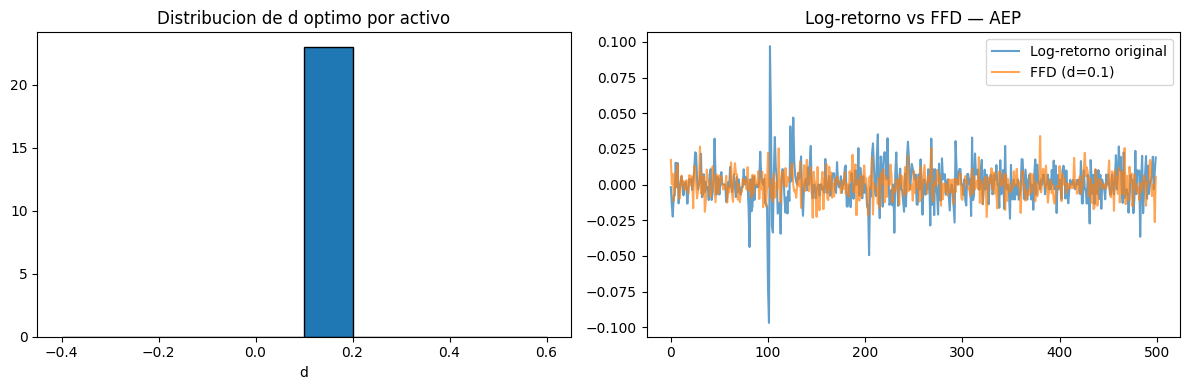

In [ ]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [ ]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


Autovalores de senyal: 1 / 23
Lambda_max (Marchenko-Pastur): 6.4682


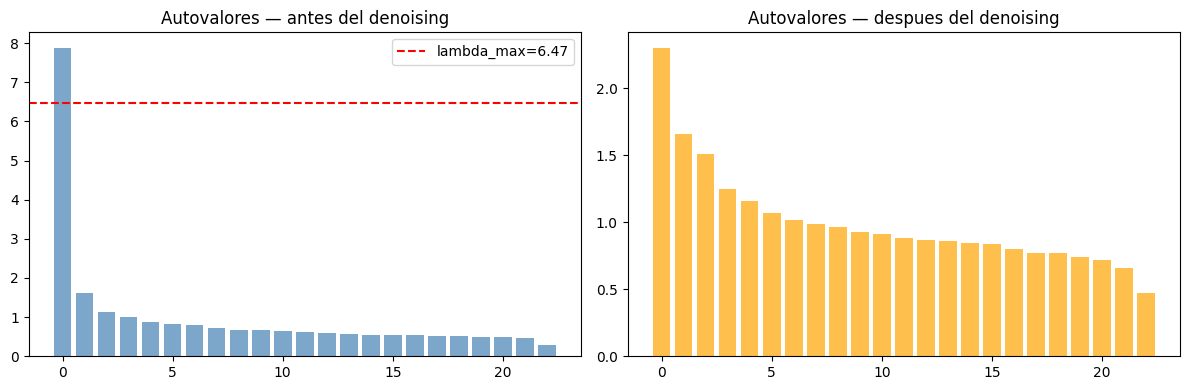

In [ ]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [ ]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


Serie preprocesada: (15691, 23)
Train: (13335, 90, 23)  Val: (702, 90, 23)  Test: (1560, 90, 23)


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

Mejor modelo Parte 1 (redes neuronales): Dense


c:\Users\Natalia\workplace\Taller4_NN\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3165 - val_loss: 0.2373 - learning_rate: 0.0010
Epoch 2/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2803 - val_loss: 0.2373 - learning_rate: 0.0010
Epoch 3/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2803 - val_loss: 0.2373 - learning_rate: 0.0010
Epoch 4/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2804 - val_loss: 0.2373 - learning_rate: 0.0010
Epoch 5/100
199/209 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2786
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2801 - val_loss: 0.2371 - learning_rate: 0.0010
Epoch 6/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2802 - val_loss: 0.2372 - learning_rate: 5.0000e-04
Epoch 7/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2797 - val_loss: 0.2373 - learning_rate: 5.0000e-04
Epoch 8/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2797 - val_loss: 0.2

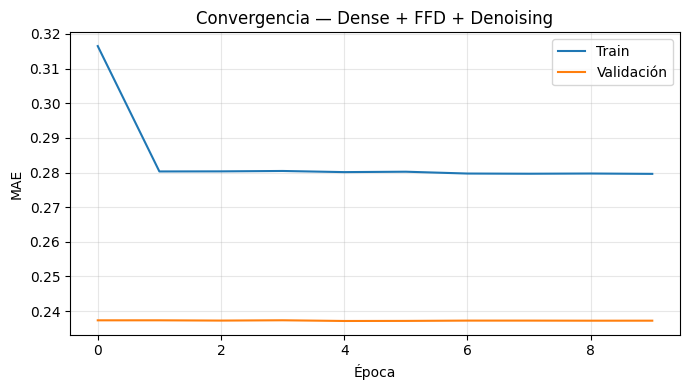

In [ ]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=50, batch_size=64, callbacks=CALLBACKS, verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

,mae_train,mae_val,mae_test,n_params
modelo,,,,
Dense,0.005237,0.004310,0.005589,566039
Dense_prep,0.279774,0.237332,0.291364,566039


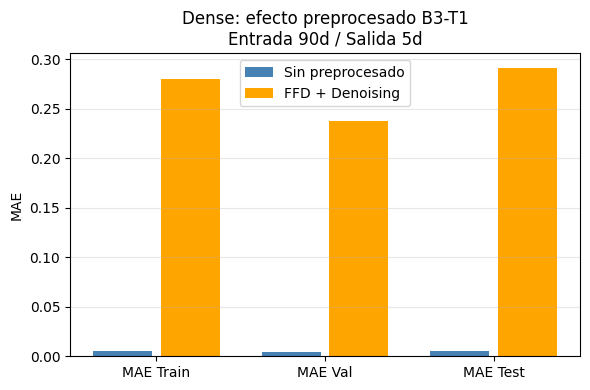

Variacion MAE test con preprocesado: -5113.1%
Resultados [investigacion] guardados en: ../resultados/metricas/ent90_sal05.json


In [ ]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
